In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("Kütüphaneler yüklendi ✅")

Kütüphaneler yüklendi ✅


In [2]:
df = pd.read_csv(r'C:\Users\Cagatay\Desktop\project\ecommerce-sql-analysis\data\online_retail_II.csv', encoding='latin-1')

print("Veri yüklendi ✅")
print(f"Satır sayısı: {df.shape[0]}")
print(f"Sütun sayısı: {df.shape[1]}")

Veri yüklendi ✅
Satır sayısı: 1067371
Sütun sayısı: 8


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [5]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Eksik Sayı': missing,
    'Eksik Yüzde (%)': missing_percent.round(2)
})

print(missing_df)

             Eksik Sayı  Eksik Yüzde (%)
Invoice               0             0.00
StockCode             0             0.00
Description        4382             0.41
Quantity              0             0.00
InvoiceDate           0             0.00
Price                 0             0.00
Customer ID      243007            22.77
Country               0             0.00


In [8]:
# Invoice'u C ile başlayanlar iptal edilmiş siparişler
print(f"İptal öncesi: {df.shape[0]} satır")

df = df[~df['Invoice'].str.startswith('C')]

print(f"İptal sonrası: {df.shape[0]} satır")
print(f"Çıkarılan iptal: {824364 - df.shape[0]}")

İptal öncesi: 824364 satır
İptal sonrası: 805620 satır
Çıkarılan iptal: 18744


In [10]:
df['Revenue'] = df['Quantity'] * df['Price']

print(f"Revenue sütunu eklendi ✅")
print(df[['Invoice', 'Quantity', 'Price', 'Revenue']].head())

Revenue sütunu eklendi ✅
  Invoice  Quantity  Price  Revenue
0  489434        12   6.95     83.4
1  489434        12   6.75     81.0
2  489434        12   6.75     81.0
3  489434        48   2.10    100.8
4  489434        24   1.25     30.0


In [11]:
# SQLite database oluştur
conn = sqlite3.connect('ecommerce.db')

# Veriyi database'e yükle
df.to_sql('orders', conn, if_exists='replace', index=False)

print("Database oluşturuldu ✅")
print("Tablo adı: orders")

Database oluşturuldu ✅
Tablo adı: orders


In [14]:
# SQL sorgusu çalıştır
query = """
SELECT COUNT(*) as toplam_satir
FROM orders
"""

result = pd.read_sql_query(query, conn)
print(result)

   toplam_satir
0        805620


In [15]:
query = """
SELECT "Customer ID",
       ROUND(SUM(Revenue), 2) as total_revenue,
       COUNT(DISTINCT Invoice) as total_orders
FROM orders
GROUP BY "Customer ID"
ORDER BY total_revenue DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
print(result)

   Customer ID  total_revenue  total_orders
0      18102.0      608821.65           145
1      14646.0      528602.52           152
2      14156.0      313946.37           156
3      14911.0      295972.63           398
4      17450.0      246973.09            51
5      13694.0      196482.81           143
6      17511.0      175603.55            60
7      16446.0      168472.50             2
8      16684.0      147142.77            55
9      12415.0      144458.37            28


In [16]:
query = """
SELECT SUBSTR(InvoiceDate, 1, 7) as month,
       ROUND(SUM(Revenue), 2) as monthly_revenue,
       COUNT(DISTINCT Invoice) as order_count
FROM orders
GROUP BY month
ORDER BY month
"""

result_monthly = pd.read_sql_query(query, conn)
print(result_monthly)

      month  monthly_revenue  order_count
0   2009-12        686654.16         1512
1   2010-01        557319.06         1011
2   2010-02        506371.07         1106
3   2010-03        699608.99         1524
4   2010-04        594609.19         1329
5   2010-05        599985.79         1377
6   2010-06        639066.58         1497
7   2010-07        591636.74         1381
8   2010-08        604242.65         1293
9   2010-09        831615.00         1689
10  2010-10       1036680.00         2133
11  2010-11       1172336.04         2587
12  2010-12        884591.89         1400
13  2011-01        569445.04          987
14  2011-02        447137.35          998
15  2011-03        595500.76         1321
16  2011-04        469200.36         1149
17  2011-05        678594.56         1555
18  2011-06        661213.69         1393
19  2011-07        600091.01         1331
20  2011-08        645343.90         1281
21  2011-09        952838.38         1756
22  2011-10       1039318.79      

In [17]:
query = """
SELECT Country,
       ROUND(SUM(Revenue), 2) as total_revenue,
       COUNT(DISTINCT "Customer ID") as customer_count
FROM orders
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10
"""

result_country = pd.read_sql_query(query, conn)
print(result_country)

          Country  total_revenue  customer_count
0  United Kingdom    14723147.52            5353
1            EIRE      621631.11               5
2     Netherlands      554232.34              22
3         Germany      431262.46             107
4          France      355257.47              95
5       Australia      169968.11              15
6           Spain      109178.53              41
7     Switzerland      100365.34              22
8          Sweden       91549.72              19
9         Denmark       69862.19              12


In [18]:
query = """
SELECT Description,
       SUM(Quantity) as total_quantity,
       ROUND(SUM(Revenue), 2) as total_revenue
FROM orders
GROUP BY Description
ORDER BY total_quantity DESC
LIMIT 10
"""

result_products = pd.read_sql_query(query, conn)
print(result_products)

                          Description  total_quantity  total_revenue
0   WORLD WAR 2 GLIDERS ASSTD DESIGNS          109169       24905.87
1  WHITE HANGING HEART T-LIGHT HOLDER           93640      252072.46
2         PAPER CRAFT , LITTLE BIRDIE           80995      168469.60
3       ASSORTED COLOUR BIRD ORNAMENT           79913      127074.17
4      MEDIUM CERAMIC TOP STORAGE JAR           77916       81416.73
5             JUMBO BAG RED RETROSPOT           75759      136980.08
6                 BROCADE RING PURSE            71129       14827.71
7  PACK OF 60 PINK PAISLEY CAKE CASES           55270       26733.45
8         60 TEATIME FAIRY CAKE CASES           53495       26121.57
9     PACK OF 72 RETROSPOT CAKE CASES           46107       22214.26


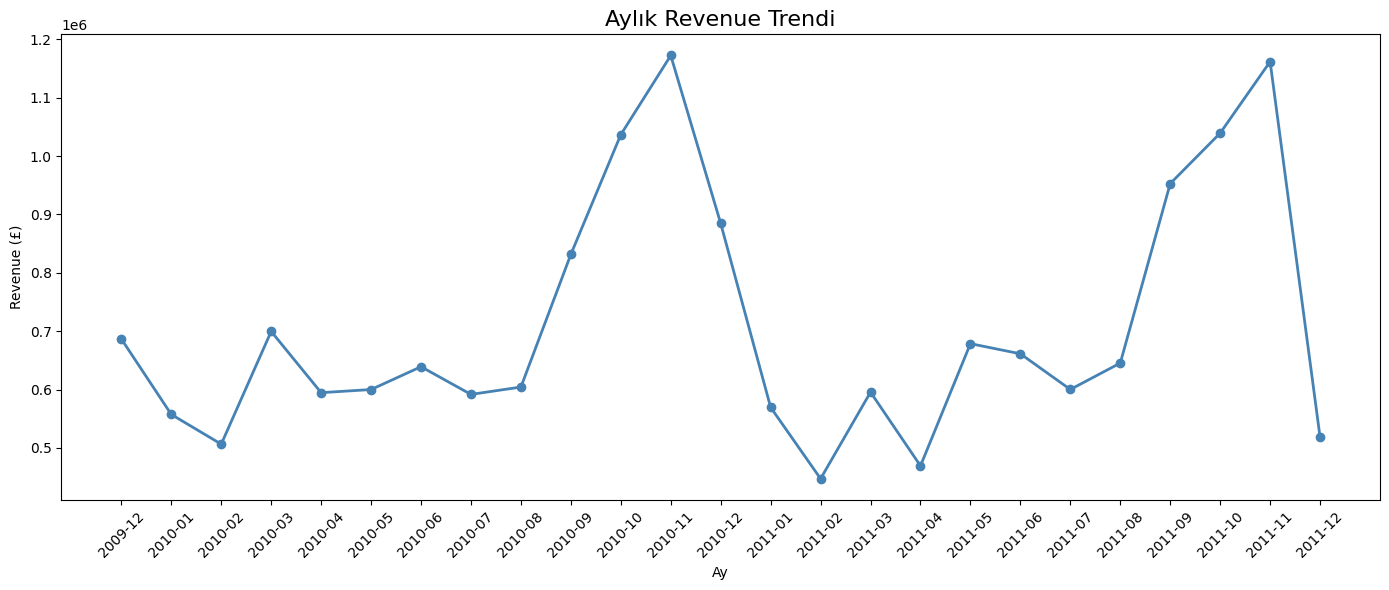

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(result_monthly['month'], 
         result_monthly['monthly_revenue'], 
         marker='o', 
         color='steelblue',
         linewidth=2)

plt.title('Aylık Revenue Trendi', fontsize=16)
plt.xlabel('Ay')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

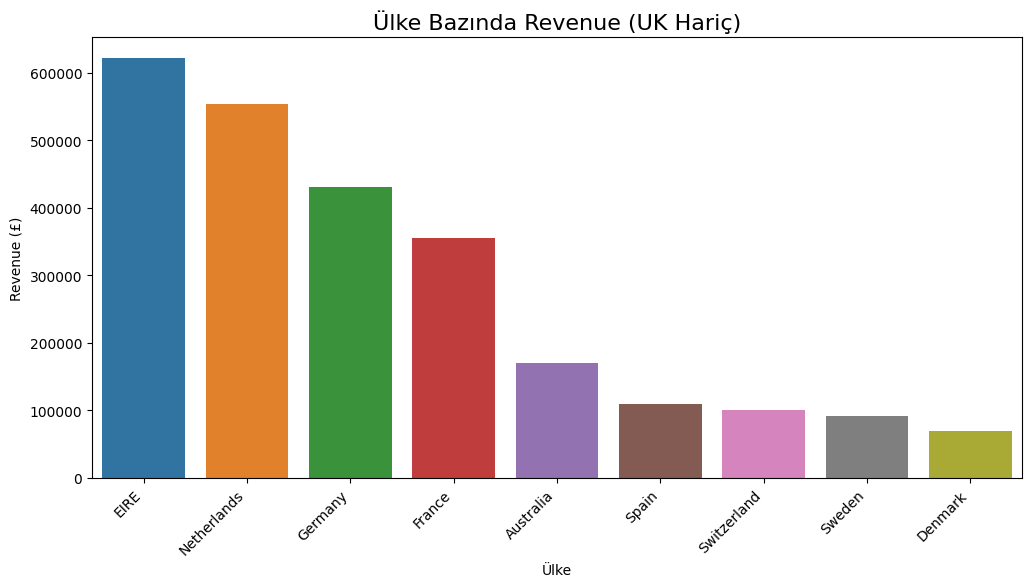

In [22]:
result_country_no_uk = result_country[result_country['Country'] != 'United Kingdom']

plt.figure(figsize=(12, 7))

sns.barplot(data=result_country_no_uk, 
            x='Country', 
            y='total_revenue',
            hue='Country',
            legend=False)

plt.title('Ülke Bazında Revenue (UK Hariç)', fontsize=16)
plt.xlabel('Ülke')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.show()

In [23]:
query = """
SELECT 
    "Customer ID",
    ROUND(julianday('2011-12-31') - julianday(MAX(InvoiceDate)), 0) as recency,
    COUNT(DISTINCT Invoice) as frequency,
    ROUND(SUM(Revenue), 2) as monetary
FROM orders
GROUP BY "Customer ID"
ORDER BY monetary DESC
LIMIT 20
"""

result_rfm = pd.read_sql_query(query, conn)
print(result_rfm)

    Customer ID  recency  frequency   monetary
0       18102.0     22.0        145  608821.65
1       14646.0     22.0        152  528602.52
2       14156.0     31.0        156  313946.37
3       14911.0     22.0        398  295972.63
4       17450.0     29.0         51  246973.09
5       13694.0     25.0        143  196482.81
6       17511.0     24.0         60  175603.55
7       16446.0     22.0          2  168472.50
8       16684.0     25.0         55  147142.77
9       12415.0     45.0         28  144458.37
10      15061.0     24.0        127  137818.52
11      16029.0     60.0        107  122209.14
12      17949.0     22.0        118  118628.08
13      15311.0     22.0        208  116771.16
14      13089.0     24.0        203  116737.86
15      12931.0     42.0         57   92347.34
16      14298.0     29.0         82   91194.49
17      15769.0     28.0         46   88704.32
18      12346.0    347.0         12   77556.46
19      13798.0     22.0        110   75836.87
